# Esame Laboratorio di Programmazione II - 22/07/2025


Scrivete chiaramente sul notebook il vostro nome e matricola e rinominate il file che consegnate come `matricola.ipynb` (la matricola è SMnumeri o ECnumeri).

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domande e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB: Potete usare anche più di una cella python per domanda e se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza etichette sugli assi o illeggibili sarà valutato meno bene di uno con etichette chiare.

Cercate di commmentare il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

## Esercizio 1

Crea un vettore NumPy con le seguenti spese annuali per l’auto (in euro) sostenute da 7 persone:
3200, 2750, 4100, 3600, 2950, 5100, 4400

1. Calcola la spesa totale complessiva sostenuta dal gruppo.

2. Le persone con spese minori di 3000 € ottengono una detrazione fiscale del 15%. Applica la modifica al vettore.

3. Quanto ha risparmiato il gruppo dopo la detrazione fiscale?


#### LEGGENDA

- **np.array([...])** -> Crea un array NumPy

- **.sum()** -> Calcola la somma di tutti gli elementi

- **array < valore** -> Confronto vettoriale, restituisce un array di booleani

- **array.copy()** -> Crea una copia indipendente dell'array

- **array[mask] *= 0.85** -> Applica lo sconto del 15% (moltiplica per 0.85) solo agli elementi selezionati dalla maschera

- **np.round(array, 2)** -> Arrotonda a 2 decimali per stampa pulita

In [ ]:
import numpy as np

# 1. Creo l'array con le spese
spese = np.array([3200, 2750, 4100, 3600, 2950, 5100, 4400], dtype=float)
print ("Spese originali:", spese.tolist())


# 2. Calcolo la spesa totale complessiva
totale_originale = spese.sum()
print (f"Spesa totale complessiva: {totale_originale} €")


# 3. Applico la detrazione del 15 % a chi spende meno di 3000 €
spese_detratte = spese.copy()   # Creo una copia 
mask = spese_detratte < 3000    # Maschera per spese < 3000
spese_detratte[mask] *= 0.85    # Applico lo sconto
print (f"Spese dopo la detrazione: {np.round(spese_detratte, 2).tolist()}")


# 4. Calcolo quanto ha risparmiato il gruppo
totale_detratto = spese_detratte.sum()
risparmio = totale_originale - totale_detratto
print (f"Totale dopo la detrazione: {totale_detratto:.2f} €")
print (f"Risparmio totale del gruppo: {risparmio:.2f} €")

Spese originali: [3200.0, 2750.0, 4100.0, 3600.0, 2950.0, 5100.0, 4400.0]
Spesa totale complessiva: 26100.0 €
Spese dopo la detrazione: [3200.0, 2337.5, 4100.0, 3600.0, 2507.5, 5100.0, 4400.0]
Totale dopo la detrazione: 25245.00 €
Risparmio totale del gruppo: 855.00 €


## Esercizio 2
1. Scrivi una funzione che simula il lancio di un dado per N volte e restituisce un array con il numero di volte che è uscita ciascuna faccia (da 1 a 6).
2. Calcolare la frequenza % con la dimensione del campione (numero di lanci) 100 volte da 10 a 5000.  Ottieni così 100 array di frequenze.
3. Fai il plot dell’andamento della frequenza media delle facce 1, 3 e 6 in funzione della dimensione del campione.



#### LEGGENDA

- **np.random.seed(0)** -> Imposta il seme per la riproducibilità dei numeri casuali

- **np.random.randint(1, 7, size=n)** -> Genera n lanci di un dado equo (valori da 1 a 6)

- **np.bincount(array, minlength=7)** -> Conta le occorrenze di ogni numero da 0 a 6 (poi si esclude l'indice 0)

- **np.linspace(start, stop, num, dtype=int)** -> Genera num valori equidistanti tra start e stop

- **list.append()** -> Aggiunge un elemento a una lista

- **np.mean(frequenze, axis=0)** -> Calcola la media delle frequenze per ogni faccia lungo le righe (axis=0)

- **plt.plot(x, y, label='...')** -> Traccia una linea

- **plt.xlabel(), plt.ylabel(), plt.title()** -> Etichette e titolo

- **plt.legend()** -> Mostra la legenda

- **plt.grid(True)** -> Aggiunge una griglia

- **plt.show()** -> Visualizza il grafico

PUNTO 1:
Test: 1000 lanci - Conteggi per faccia 1..6: [171, 157, 157, 183, 161, 171]
Test: somma dei conteggi = 1000 

PUNTO 2:
Prime 5 dimensioni del campione: [10, 60, 110, 161, 211]
Ultime 5 dimensioni del campione: 4798 

PUNTO 3:
Numero di campioni calcolati: 100
Prime 3 frequenze (prime 3 dimensioni, per faccia 1..6):
 n=10: [10.0, 30.0, 20.0, 20.0, 20.0, 0.0]
 n=60: [8.33, 20.0, 18.33, 20.0, 13.33, 20.0]
 n=110: [15.45, 18.18, 14.55, 20.0, 15.45, 16.36]


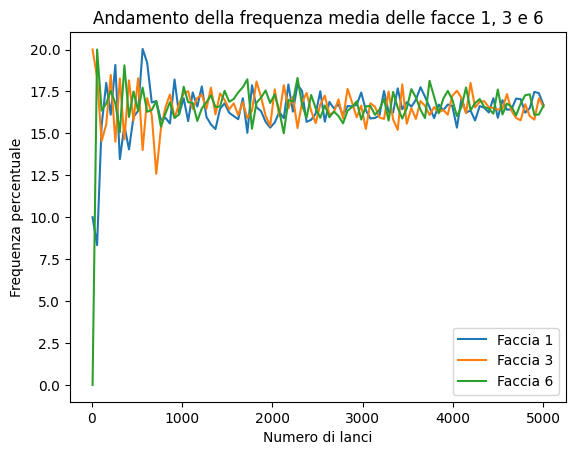

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Imposto il seed per riproducibilità
np.random.seed(0)


# 1. Definisco la funzione che simula N lanci e definisce i conteggi
def conteggi_dado(N):
    lanci = np.random.randint(1, 7, size=N)              # Valori da 1 a 6
    conteggi = np.bincount(lanci, minlength=7) [1:]      # Escludo l'indice 0
    return conteggi

# Test veloce della funzione
test_conteggi = conteggi_dado(1000)
print ("PUNTO 1:")
print ("Test: 1000 lanci - Conteggi per faccia 1..6:", test_conteggi.tolist())
print ("Test: somma dei conteggi =", sum(test_conteggi), "\n")


# 2. Dimensione del campione: 100 valori da 10 a 5000
dimensioni = np.linspace(10, 5000, 100, dtype=int)
print ("PUNTO 2:")
print ("Prime 5 dimensioni del campione:", dimensioni[:5].tolist())
print ("Ultime 5 dimensioni del campione:", dimensioni[-5].tolist(), "\n")


# 3. Per ogni dimensione, calcolo le frequenze percentuali di ogni faccia
frequenze_percentuali = []              # Sarà una lista di 100 array, ognuno di 6 elementi

for n in dimensioni:
    conteggi = conteggi_dado(n)
    freq = (conteggi / n) * 100         # Frequenza percentuale
    frequenze_percentuali.append(freq)

print ("PUNTO 3:")
print (f"Numero di campioni calcolati: {len(frequenze_percentuali)}")
print ("Prime 3 frequenze (prime 3 dimensioni, per faccia 1..6):")
for i in range(3):
    print (f" n={dimensioni[i]}: {np.round(frequenze_percentuali[i], 2).tolist()}")


# 4. Estraggo le frequenze medie per le facce 1, 3 e 6
faccia1 = [arr[0] for arr in frequenze_percentuali]         # faccia 1
faccia3 = [arr[2] for arr in frequenze_percentuali]         # faccia 3
faccia6 = [arr[5] for arr in frequenze_percentuali]         # faccia 6

# 5. Grafico
plt.plot(dimensioni, faccia1, label='Faccia 1')
plt.plot(dimensioni, faccia3, label='Faccia 3')
plt.plot(dimensioni, faccia6, label='Faccia 6')
plt.xlabel('Numero di lanci')
plt.ylabel('Frequenza percentuale')
plt.title('Andamento della frequenza media delle facce 1, 3 e 6')
plt.legend()
plt.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni 7 x 7, con valori estratti da una distribuzione normale con media = 0, ed std = 5.

2. Per ogni riga, identifica il valore più lontano da zero (cioè con valore assoluto massimo). Crea un array con questi 7 valori (uno per riga).

3. Calcola quante di queste righe hanno il valore più lontano da zero positivo?

#### LEGGENDA

- **np.random.normal(media, std, size)** -> Genera una matrice con distribuzione normale

- **np.abs(array)** -> Calcola il valore assoluto elemento per elemento

- **np.argmax(array)** -> Restituisce l'indice del valore massimo

- **riga[indice]** -> Estrae il valore in quella posizione

- **valore > 0** -> Maschera booleana per valori positivi

- **.sum()** -> Conta i True (in una maschera booleana)

In [108]:
import numpy as np

# 1. Genero la matrice (media = 0, std = 5, seed = 0)
np.random.seed(0)
matrice = np.random.normal(0, 5, (7, 7))
print ("PUNTO 1: Matrice generata (7x7)")
print (matrice, "\n")


# 2. Per ogni riga, trovo il valore con il massimo valore assoluto (VMA)
valori_max_abs = []     # Lista per raccogliere i valori
print ("PUNTO 2: Array dei valori più lontani da zero per ogni riga:")
for i in range(7):
    riga = matrice[i]
    indice_max = np.argmax(np.abs(riga))    # Trovo l'indice del VMA
    valore = riga[indice_max]               # Estraggo il valore
    valori_max_abs.append(valore)
    print(f"riga {i+1}: valore più lontano da zero = {valore:.4f}")

# 3. Conto quanti sono positivi
positivi = np.sum(np.array(valori_max_abs) > 0)
print (" \n PUNTO 3")
print (f"Numero di righe con valore più lontano da zero positivo: {positivi}")



PUNTO 1: Matrice generata (7x7)
[[  8.82026173   2.00078604   4.89368992  11.204466     9.33778995
   -4.8863894    4.75044209]
 [ -0.75678604  -0.51609426   2.05299251   0.72021786   7.27136753
    3.80518863   0.60837508]
 [  2.21931616   1.66837164   7.47039537  -1.02579132   1.56533851
   -4.2704787  -12.76494908]
 [  3.26809298   4.32218099  -3.7108251   11.34877312  -7.27182837
    0.22879259  -0.93591925]
 [  7.66389607   7.34679385   0.77473713   1.8908126   -4.43892874
   -9.90398234  -1.73956075]
 [  0.78174485   6.1514534    6.01189924  -1.93663409  -1.51151375
   -5.24276483  -7.10008969]
 [ -8.53135095   9.75387698  -2.54826091  -2.19037151  -6.2639768
    3.88745178  -8.06948924]] 

PUNTO 2: Array dei valori più lontani da zero per ogni riga:
riga 1: valore più lontano da zero = 11.2045
riga 2: valore più lontano da zero = 7.2714
riga 3: valore più lontano da zero = -12.7649
riga 4: valore più lontano da zero = 11.3488
riga 5: valore più lontano da zero = -9.9040
riga 6: 

## Esercizio 4 

Utilizza il dataset cereal.csv.

Contiene dati nutrizionali (proteine, fibre, calorie, zuccheri, ecc.) per circa 70 cereali.


1.  Aggiungi una colonna chiamata `nutri_score`, definita come:
$$
\texttt{nutri\_score} = \frac{\texttt{protein} + \texttt{fiber}}{\texttt{calories}}
$$

Indica quanti nutrienti positivi ci sono per ogni caloria: più è alto, più il cereale è "nutriente a parità di energia.

2. Trova i **5 cereali con il `nutri_score` più alto** e stampali con `name` e `nutri_score`.

3. Filtra i cereali che soddisfano entrambi i criteri:

   - meno di 120 calorie  
   - più di 2 grammi di fibra 


4. **Crea un grafico a barre** dei **10 cereali con il `nutri_score` più alto**, usando `name` sull’asse x.

5. Crea uno **scatter plot** (grafico a punti) che visualizzi:

   - `calories` sull’asse x  
   - `nutri_score` sull’asse y
   - `protein` nel colore dei punti


#### LEGGENDA (Esercizio 4 – cereal.csv)

- **pd.read_csv('cereal.csv', sep=';')** -> Legge il CSV con separatore punto e virgola

- **df['nuova'] = (df['col1'] + df['col2']) / df['col3']** -> Crea una nuova colonna con un'operazione

- **df.nlargest(n, 'col')** -> Restituisce le n righe con i valori più alti nella colonna

- **df[condizione1 & condizione2]** -> Filtra il DataFrame con due condizioni

- **len(df)** -> Numero di righe

- **plt.figure(figsize=(larghezza, altezza))** -> Imposta le dimensioni della figura (in pollici)

- **plt.bar(x, y)** -> Grafico a barre verticali

- **plt.xticks(rotation=45, ha='right')** -> Ruota le etichette dell'asse x di 45 gradi e le allinea a destra (evita sovrapposizioni)

- **plt.tight_layout()** -> Regola automaticamente i margini per evitare tagli di etichette o titoli

- **plt.xlabel(), plt.ylabel(), plt.title()** -> Etichette e titolo

- **plt.scatter(x, y, c=colore)** -> Grafico a punti, con colore basato su una terza colonna

- **plt.colorbar(label='...')** -> Mostra la barra dei colori con etichetta

- **plt.show()** -> Visualizza il grafico

PUNTO 1: Colonna aggiunta. Ecco le prime 2 righe: 
                name  nutri_score
0          100% Bran     0.200000
1  100% Natural Bran     0.041667 

PUNTO 2: I 5 cereali con nutri_score più alto sono:
                         name  nutri_score
3   All-Bran with Extra Fiber     0.360000
0                   100% Bran     0.200000
2                    All-Bran     0.185714
9                 Bran Flakes     0.088889
64     Shredded Wheat 'n'Bran     0.077778 

PUNTO 3:
I cereali con calorie < 120 e fibra > 2 sono: 19
                        name  calories  fiber
0                  100% Bran        70   10.0
2                   All-Bran        70    9.0
3  All-Bran with Extra Fiber        50   14.0
8                  Bran Chex        90    4.0
9                Bran Flakes        90    5.0

PUNTO 4: Grafico a barre


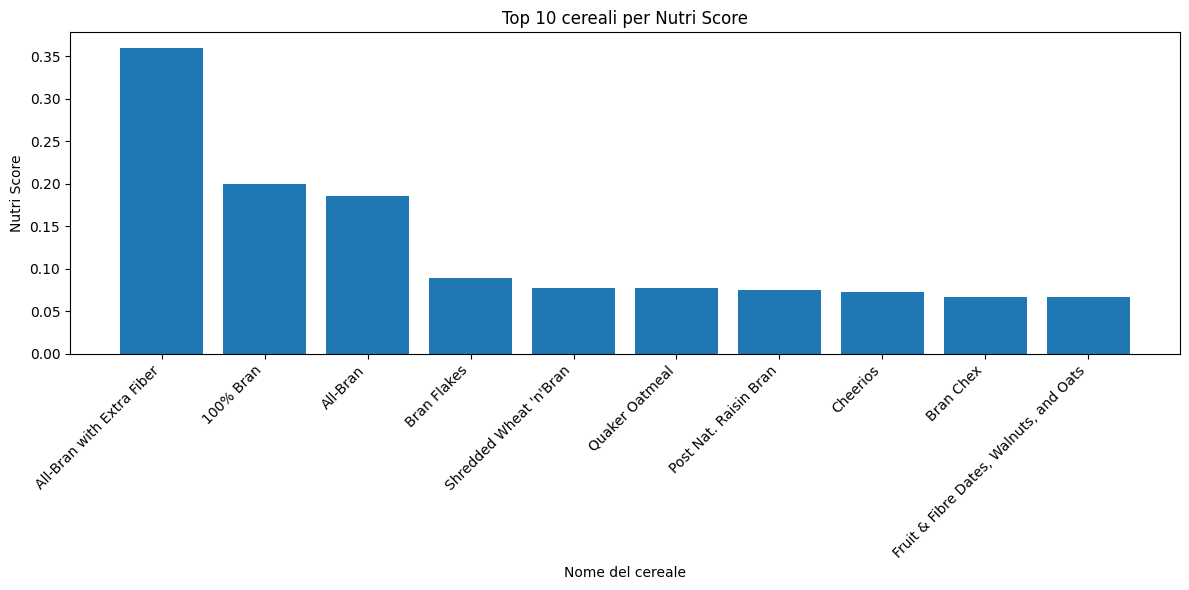


PUNTO 5: Scatter plot


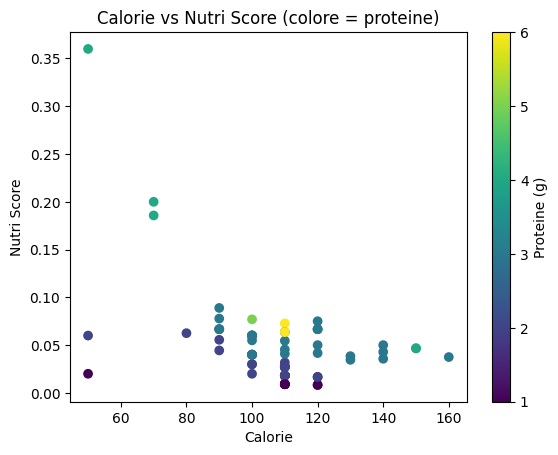

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carico il dataset e aggiungo nutri_score
df = pd.read_csv('cereal.csv', sep=';')                             # Carico dataset
df['nutri_score'] = (df['protein'] + df['fiber']) / df['calories']  # Aggiunto nutri_score
print ("PUNTO 1: Colonna aggiunta. Ecco le prime 2 righe: ")
print(df[['name', 'nutri_score']].head(2), "\n")


# 2. 5 Cereali con nutri_score più alto
top5 = df.nlargest(5,'nutri_score')
print ("PUNTO 2: I 5 cereali con nutri_score più alto sono:")
print(top5[['name', 'nutri_score']], "\n")


# 3. Filtro i cereali (calorie < 120 e fibra > 2) 
filtro = df[(df['calories'] < 120) & (df['fiber'] > 2)]
print ("PUNTO 3:")
print(f"I cereali con calorie < 120 e fibra > 2 sono: {len(filtro)}")
print(filtro[['name', 'calories', 'fiber']].head())


# 4. Grafico a barre dei 10 cereali con nutri_score più alto
print("\nPUNTO 4: Grafico a barre")
top10 = df.nlargest(10, 'nutri_score')
plt.figure(figsize=(12, 6))                    # Figura più larga
plt.bar(top10['name'], top10['nutri_score'])
plt.xticks(rotation=45, ha='right')            # Ruota e allinea
plt.xlabel('Nome del cereale')
plt.ylabel('Nutri Score')
plt.title('Top 10 cereali per Nutri Score')
plt.tight_layout()                             # Aggiusta i margini
plt.show()


# 5. Scatter plot calories vs nutri_score, colore = protein
print("\nPUNTO 5: Scatter plot")
plt.scatter(df['calories'], df['nutri_score'], c=df['protein'])
plt.colorbar(label='Proteine (g)')
plt.xlabel('Calorie')
plt.ylabel('Nutri Score')
plt.title('Calorie vs Nutri Score (colore = proteine)')
plt.show()

## Esercizio 5 

Utilizza il dataset `imdb_top_1000.csv`, che contiene informazioni su 1000 film recensiti su IMDB.

1. Quanti **valori mancanti** ci sono per colonna? Elimina le righe con i valori mancanti.

2. Elimina la colonna `Overview`. Aggiungi una colonna (`main_genre`) con solo il primo genere della colonna `genre`. Quali sono i 5 generi più frequenti?

3. Che attore/attrice è stato/a più volte la `Star1` e quello/a che ha fatto più film.

4. Calcola l'IMDB_rating medio e il Gross medio di ogni genere. Fai uno scatter plot dell'IMDB_rating medio e il Gross medio di ogni genere. Riesci a mettere anche l'ettichetta del genere?

5. Visualizza la distribuzione del IMDB_rating  e la distribuzione del `Gross` dei primi 5 main_genre. (Hint fai due violin plot).




#### LEGGENDA

- **pd.read_csv('imdb_top_1000.csv')** -> Carica il dataset

- **df.isnull().sum()** -> Conta i valori mancanti per colonna

- **df.dropna()** -> Elimina le righe con qualsiasi valore mancante

- **df.drop(columns=['col'])**, **df['nuova']** -> Elimina/aggiunge colonne

- **df['col'].str.split(',').str[0]** -> Estrae il primo genere dalla stringa

- **df['col'].value_counts().head(5)** -> Conta le frequenze e mostra le prime 5

- **df.groupby('genere')['col'].mean()** -> Media raggruppata

- **plt.scatter(x, y)** -> Grafico a punti

- **plt.annotate()** -> Aggiunge etichette (generi) ai punti

- **sns.violinplot(x='genere', y='valore', data=df)** -> Violin plot

PUNTO 1:
- Dimensioni originali: (1000, 15) 

- Valori mancanti per colonne: 
 Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64 

- Dimensioni del database dopo dropna: (714, 15)

 PUNTO 2:
I 5 generi più frequenti sono:
 main_genre
Drama        192
Action       127
Comedy       104
Crime         74
Biography     73
Name: count, dtype: int64

 PUNTO 3:
Attore/attrice più presente come Star1: Tom Hanks (12 film)

 PUNTO 4:


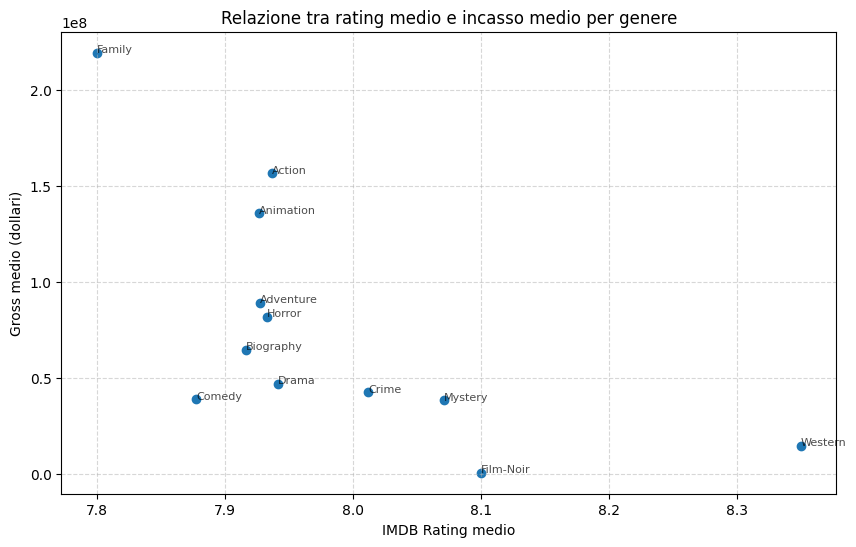


PUNTO 5


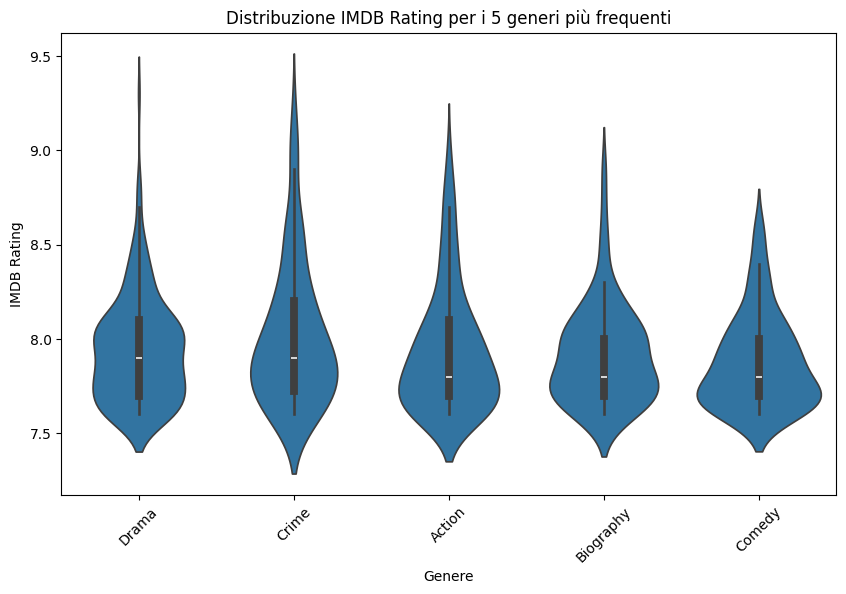

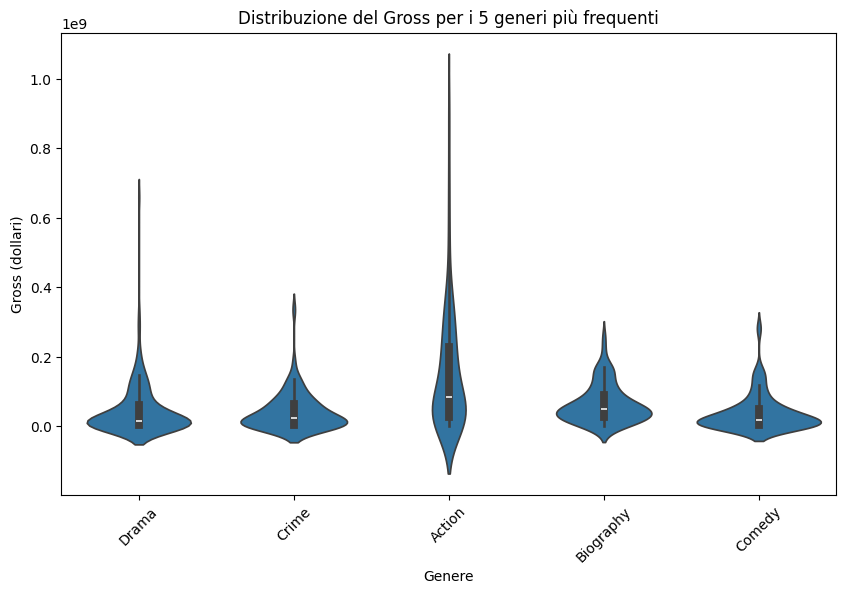

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carico il dataset, controllo i NaN ed elimino righe con NaN
df = pd.read_csv ('imdb_top_1000.csv')
print ("PUNTO 1:")
print ("- Dimensioni originali:", df.shape, "\n")
print ("- Valori mancanti per colonne: \n", df.isnull().sum(), "\n")

# Elimino le righe con qualsiasi NaN
df = df.dropna()
print("- Dimensioni del database dopo dropna:", df.shape)


# 2. Elimino colonna Overview e aggiungo main_genre
df = df.drop(columns=['Overview'])                          # Elimino colonna
df['main_genre'] = df['Genre'].str.split(',').str[0]        # Primo genere
print ("\n PUNTO 2:")
print ("I 5 generi più frequenti sono:\n", df['main_genre'].value_counts().head(5))


# 3. Attore/attrice più frequente in Star1
print ("\n PUNTO 3:")
star1_counts = df['Star1'].value_counts()
top_star = star1_counts.idxmax()
top_count = star1_counts.max()
print (f"Attore/attrice più presente come Star1: {top_star} ({top_count} film)")


# 4. Media rating e Gross per genre, scatter plot con etichette
print ("\n PUNTO 4:")

# Media per genere
media_rating = df.groupby('main_genre')['IMDB_Rating'].mean()
media_gross = df.groupby('main_genre')['Gross'].mean()

# Creo un DataFrame per il plot
df_plot = pd.DataFrame({'rating': media_rating, 'gross': media_gross})
df_plot = df_plot.reset_index()  # main_genre diventa colonna

plt.figure(figsize=(10,6))
plt.scatter(df_plot['rating'], df_plot['gross'])

# Aggiungo etichette per ogni punto
for i, row in df_plot.iterrows():
    plt.annotate(row['main_genre'], (row['rating'], row['gross']),
                 fontsize=8, alpha=0.7)

plt.xlabel('IMDB Rating medio')
plt.ylabel('Gross medio (dollari)')
plt.title('Relazione tra rating medio e incasso medio per genere')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# 5. Violin plot per rating e gross dei primi 5 generi
print("\nPUNTO 5")
top5_genres = df['main_genre'].value_counts().head(5).index.tolist()
df_top5 = df[df['main_genre'].isin(top5_genres)]

# Violin plot per IMDB_Rating
plt.figure(figsize=(10,6))
sns.violinplot(x='main_genre', y='IMDB_Rating', data=df_top5)
plt.xlabel('Genere')
plt.ylabel('IMDB Rating')
plt.title('Distribuzione IMDB Rating per i 5 generi più frequenti')
plt.xticks(rotation=45)
plt.show()

# Violin plot per Gross
plt.figure(figsize=(10,6))
sns.violinplot(x='main_genre', y='Gross', data=df_top5)
plt.xlabel('Genere')
plt.ylabel('Gross (dollari)')
plt.title('Distribuzione del Gross per i 5 generi più frequenti')
plt.xticks(rotation=45)
plt.show()

## Esercizio 6

Considera i seguenti dati, che :

`x = np.linspace(0, 10, 100)`  
`y = -3.5 * x + 2 + np.random.normal(0, 10, 100)`

Cerca di riprodurre la retta fittando i parametri della funzione y = ax + b.

1. Stima i parametri della retta.
2. Calcola l’intervallo di confidenza al 95% dei parametri a e b.
N.B il secondo output del metodo curve_fit è proprio la matrice di covarianza: `params, cov = curve_fit(retta, x, y)`. 
L'**errore standard** di ciascun parametro si calcola come:

$$
\text{errore\_standard}_i = \sqrt{\text{cov}(i, i)}
$$

dove $\text{cov}(i, i)$ è l'elemento diagonale $i$-esimo della **matrice di covarianza**.

L’**intervallo di confidenza al 95%** si approssima con:

$$
\text{parametro}_i \pm 1.96 \times \text{errore\_standard}_i
$$
3. Plotta i punti originali e la retta ottenuta con anche l'intervallo di confidenza

#### LEGGENDA

- **np.linspace(0, 10, 100)** -> Crea 100 punti equidistanti tra 0 e 10

- **np.random.normal(0, 10, 100)** -> Genera 100 errori casuali con media 0 e std 10

- **curve_fit(modello, x, y)** -> Restituisce parametri ottimizzati (popt) e matrice di covarianza (pcov)

- **np.sqrt(np.diag(pcov))** -> Calcola l'errore standard per ogni parametro (radice quadrata degli elementi diagonali)

- **parametro ± 1.96 * errore_standard** -> Intervallo di confidenza al 95%

- **plt.fill_between(x, y_inf, y_sup, alpha=0.3)** -> Area di confidenza attorno alla retta

- **plt.plot(x, y_pred, 'r-')** -> Retta stimata

- **plt.scatter(x, y, s=10)** -> Punti osservati

PUNTO 1: Parametri stimati:
a (pendenza) = -3.7973
b (intercetta) = 4.0847

PUNTO 2 - Intervalli di confidenza (95%):
a: [-4.4792, -3.1155]
b: [0.1381, 8.0313]

PUNTO 3 - Plot dei punti


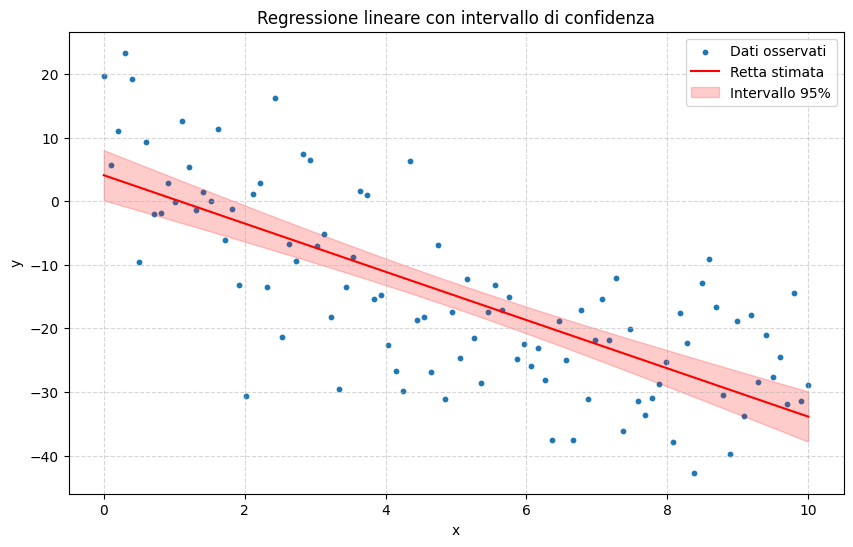

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Genero i dati (seed = 0)
np.random.seed(0)
x = np.linspace(0, 10, 100)
y = -3.5 * x + 2 + np.random.normal(0, 10, 100)


# 1. Definisco il modello e stimo i parametri
def modello_lineare(x, a, b):
    return a * x + b

popt, pcov = curve_fit(modello_lineare, x, y)
a, b = popt
print("PUNTO 1: Parametri stimati:")
print(f"a (pendenza) = {a:.4f}")
print(f"b (intercetta) = {b:.4f}")


# 2. Intervallo di confidenza al 95% per i parametri
err_a = np.sqrt(pcov[0, 0])
err_b = np.sqrt(pcov[1, 1])

conf_a = (a - 1.96 * err_a, a + 1.96 * err_a)
conf_b = (b - 1.96 * err_b, b + 1.96 * err_b)

print("\nPUNTO 2 - Intervalli di confidenza (95%):")
print(f"a: [{conf_a[0]:.4f}, {conf_a[1]:.4f}]")
print(f"b: [{conf_b[0]:.4f}, {conf_b[1]:.4f}]")


# 3. Plot punti e retta con fascia di confidenza
print("\nPUNTO 3 - Plot dei punti")
y_pred = modello_lineare(x, a, b)

# Calcolo la fascia di confidenza per la retta (usando la propagazione)
var_pred = pcov[0,0] * x**2 + pcov[1,1] + 2 * x * pcov[0,1]
std_pred = np.sqrt(var_pred)
y_upper = y_pred + 1.96 * std_pred
y_lower = y_pred - 1.96 * std_pred

plt.figure(figsize=(10,6))
plt.scatter(x, y, s=10, label='Dati osservati')
plt.plot(x, y_pred, 'r-', label='Retta stimata')
plt.fill_between(x, y_lower, y_upper, color='red', alpha=0.2, label='Intervallo 95%')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressione lineare con intervallo di confidenza')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
